In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [12]:
df = pd.read_csv('zomato.csv')

In [13]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

In [15]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
def clean_rating(value):
    value = str(value).strip()
    if '/' in value:
        value = value.split('/')[0] # Takes just the '4.1' out of '4.1/5'
    try:
        return float(value)
    except ValueError:
        return np.nan # Turns text like '\nTop floor' or 'NEW' into a missing value
df['rate'] = df['rate'].apply(clean_rating)
print("Data types after cleaning:")
print(df[['approx_cost(for two people)', 'rate']].dtypes)
print("\nFirst 5 clean rows:")
df[['name', 'approx_cost(for two people)', 'rate']].head()

Data types after cleaning:
approx_cost(for two people)    float64
rate                           float64
dtype: object

First 5 clean rows:


,name,approx_cost(for two people),rate
0,Jalsa,800.0,4.1
1,Spice Elephant,800.0,4.1
2,San Churro Cafe,800.0,3.8
3,Addhuri Udupi Bhojana,300.0,3.7
4,Grand Village,600.0,3.8


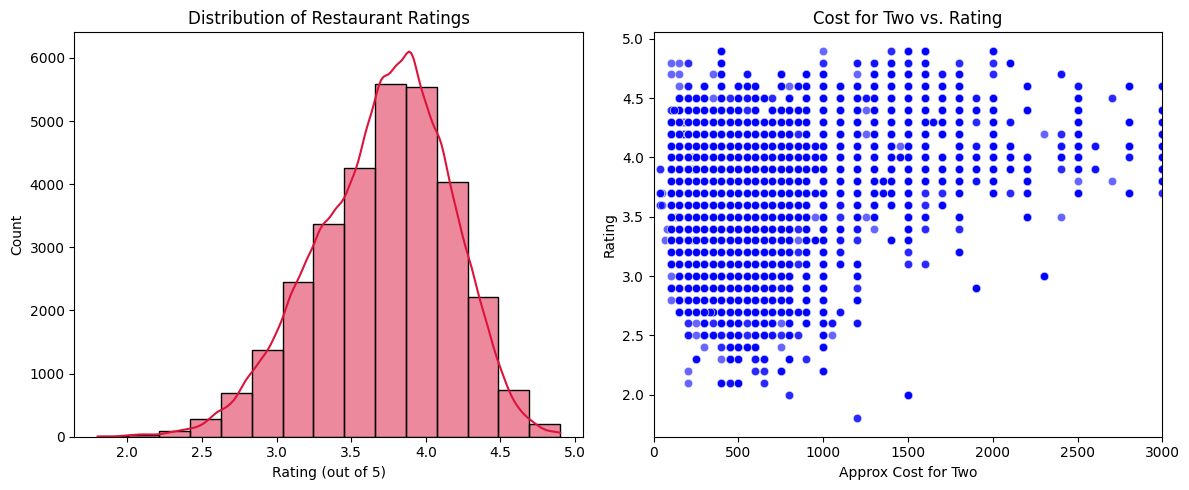

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for your plots
plt.figure(figsize=(12, 5))

# Plot 1: Most popular rating counts
plt.subplot(1, 2, 1)
sns.histplot(df['rate'].dropna(), bins=15, kde=True, color='crimson')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating (out of 5)')

# Plot 2: Cost versus Rating
plt.subplot(1, 2, 2)
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df, alpha=0.6, color='blue')
plt.title('Cost for Two vs. Rating')
plt.xlabel('Approx Cost for Two')
plt.ylabel('Rating')
plt.xlim(0, 3000) # Limits view to common price ranges

plt.tight_layout()
plt.show()

In [21]:
# Check how many restaurants offer online orders
print("--- Online Order Counts ---")
print(df['online_order'].value_counts())

print("\n" + "="*40 + "\n")

# Check the average rating for online vs offline restaurants
print("--- Average Rating by Online Order Status ---")
print(df.groupby('online_order')['rate'].mean())

--- Online Order Counts ---
online_order
Yes                                                                                                                                                                                              21926
No                                                                                                                                                                                               14476
 ('Rated 4.0'                                                                                                                                                                                      447
 ('Rated 5.0'                                                                                                                                                                                      366
 ('Rated 3.0'                                                                                                                                                      